In [49]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np
import sr_fun
importlib.reload(sr_fun)
import pandas as pd
import re

# IOB Fits


Reading from configuration file: conf/iob_0.ini

Reading from configuration file: conf/selection_0.ini

Target: log10A

All model lengths:
[ 5  6  7  8  9 10 11 12 14 15 16 17 18 20 21 22 24 25 26 27 30 32 33 35
 37 42 48 64]

Equation requested:
(0.000326 + (1.001320 * ((((((((0.968112 * X5) - (-0.305871)) + exp(((-6.564060) * X1))) / (sqrt(1 + (exp((0.727894 * X5)) + (-0.466985)) ^ 2))) * (((0.375320 * X5) - ((-12.080647) * X1)) - (-0.766044))) / (sqrt(1 + (((-0.755907) + ((-3.302937) * X2)) - (((-2.577873) * X5) - ((-0.391492) * X1))) ^ 2))) * ((((-1.178872) * X5) - (-1.161970)) + exp(((((-13.897750) * X5) + ((-15.200549) * X4)) + ((5.217659 * X1) * (-5.910147)))))) / (sqrt(1 + (((0.782972 + (8.308087 * X1)) * (exp(((-3.298620) * X5)) + 0.009467)) * (((2.887967 * X5) - 0.603006) + exp((((2.447675 * X5) + (0.036507 * X4)) + ((2.435807 * X1) * (-2.050645)))))) ^ 2)))))

Equation with pars
0.000326 + 1.00132*(12.080647*IOB1 + 0.37532*lam + 0.766044)*(-1.178872*lam + exp(-30.8371316858

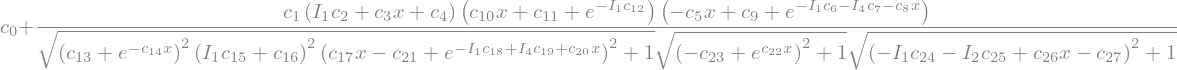


Latex version:
c_{0} + \frac{c_{1} \left(I_{1} c_{2} + c_{3} x + c_{4}\right) \left(c_{10} x + c_{11} + e^{- I_{1} c_{12}}\right) \left(- c_{5} x + c_{9} + e^{- I_{1} c_{6} - I_{4} c_{7} - c_{8} x}\right)}{\sqrt{\left(c_{13} + e^{- c_{14} x}\right)^{2} \left(I_{1} c_{15} + c_{16}\right)^{2} \left(c_{17} x - c_{21} + e^{- I_{1} c_{18} + I_{4} c_{19} + c_{20} x}\right)^{2} + 1} \sqrt{\left(- c_{23} + e^{c_{22} x}\right)^{2} + 1} \sqrt{\left(- I_{1} c_{24} - I_{2} c_{25} + c_{26} x - c_{27}\right)^{2} + 1}}

Value at x=1:


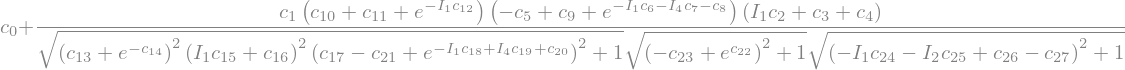


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Reparameterising expression:
Original number of parameters: 31
Temporary global prefix: b, temporary local prefix: d
Old local parameters: ['IOB1', 'IOB2', 'IOB4']
Final number of parameters: 21
Of which global: 15 and local: 6
Final values: [-0.466985000000000, -13.8977500000000, 2.887967, 0.968112, 0.727894, -3.29862000000000, 0.37532, 1.00132, 1.16197, 0.009467, 0.000326, 2.447675, -0.603006000000000, 2.577873, -1.17887200000000]
Local replacements: {B0: -IOB1*c24 - IOB2*c25 - c27, B1: IOB1*c15 + c16, B2: -IOB1*c18 + IOB4*c19, B3: c11 + exp(-IOB1*c12), B4: IOB1*c2 + c4, B5: -IOB1*c6 - IOB4*c7}


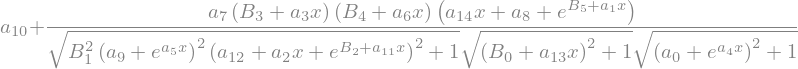


Latex version:
a_{10} + \frac{a_{7} \left(B_{3} + a_{3} x\right) \left(B_{4} + a_{6} x\right) \left(a_{14} x + a_{8} + e^{B_{5} + a_{1} x}\right)}{\sqrt{B_{1}^{2} \left(a_{9} + e^{a_{5} x}\right)^{2} \left(a_{12} + a_{2} x + e^{B_{2} + a_{11} x}\right)^{2} + 1} \sqrt{\left(B_{0} + a_{13} x\right)^{2} + 1} \sqrt{\left(a_{0} + e^{a_{4} x}\right)^{2} + 1}}

Value at x=1:


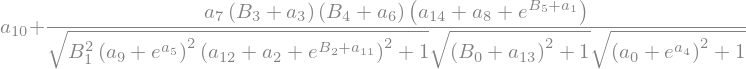

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Generating code...
Saved code to sr_fun.py

Reading from configuration file: conf/iob_0.ini

Reading from configuration file: conf/selection_0.ini

Target: log10A

RMSE train: 6.554e-01
		2 sigma: -3.546306809986597 2.541082733844838
		1 sigma: -1.8287839003276778 1.206515874112653
		RMSE: 0.6554479729408655
		RMAE: 0.31159504383122766
		2 sigma: -0.31188403439504686 0.556923236666553
		1 sigma: -0.1628685653195992 0.3361102687696142
Median absolute DF/F 0.019901119422453095
RMSE DF/F 0.10720811482573808

RMSE val: 6.255e-01
		2 sigma: -3.3569236451248385 2.5500641968360447
		1 sigma: -1.814801438240764 1.1824169700788838
		RMSE: 0.6255122077934675
		RMAE: 0.3110393305208729
		2 sigma: -0.27998005003910276 0.5232930208341373
		1 sigma: -0.158507797908524 0.3372238379079351
Median absolut

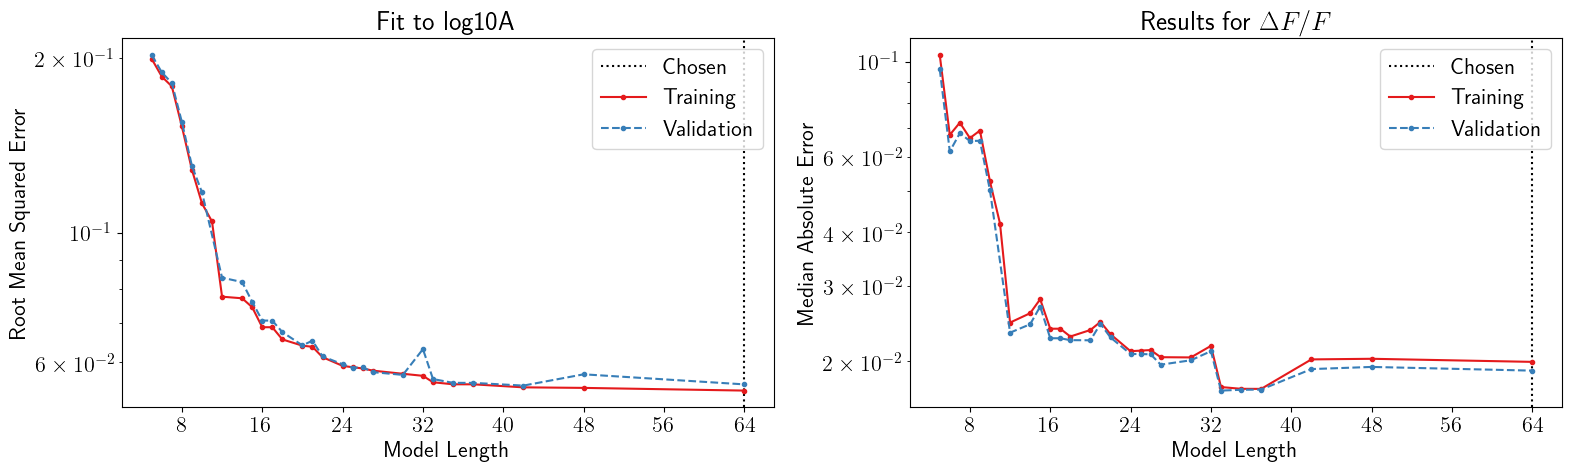

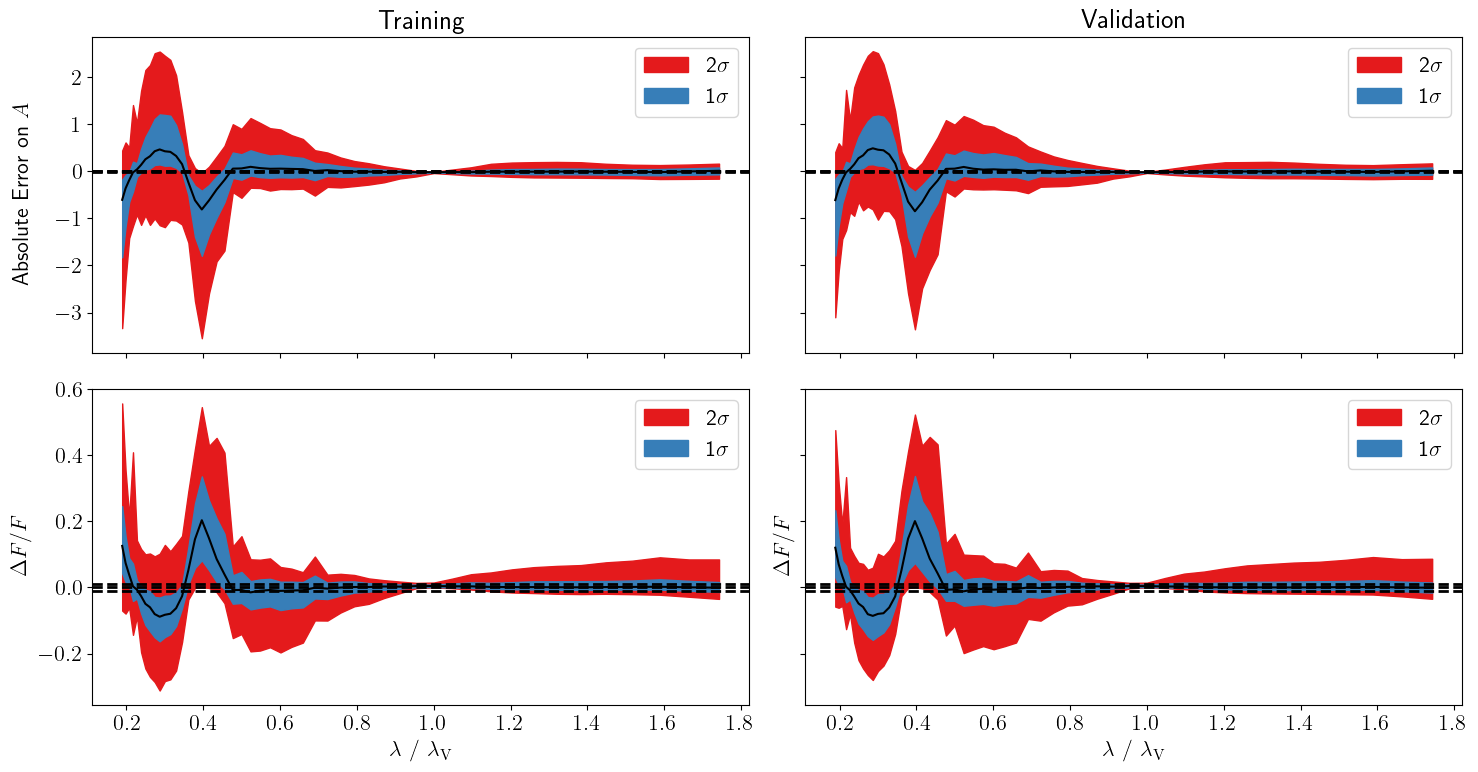

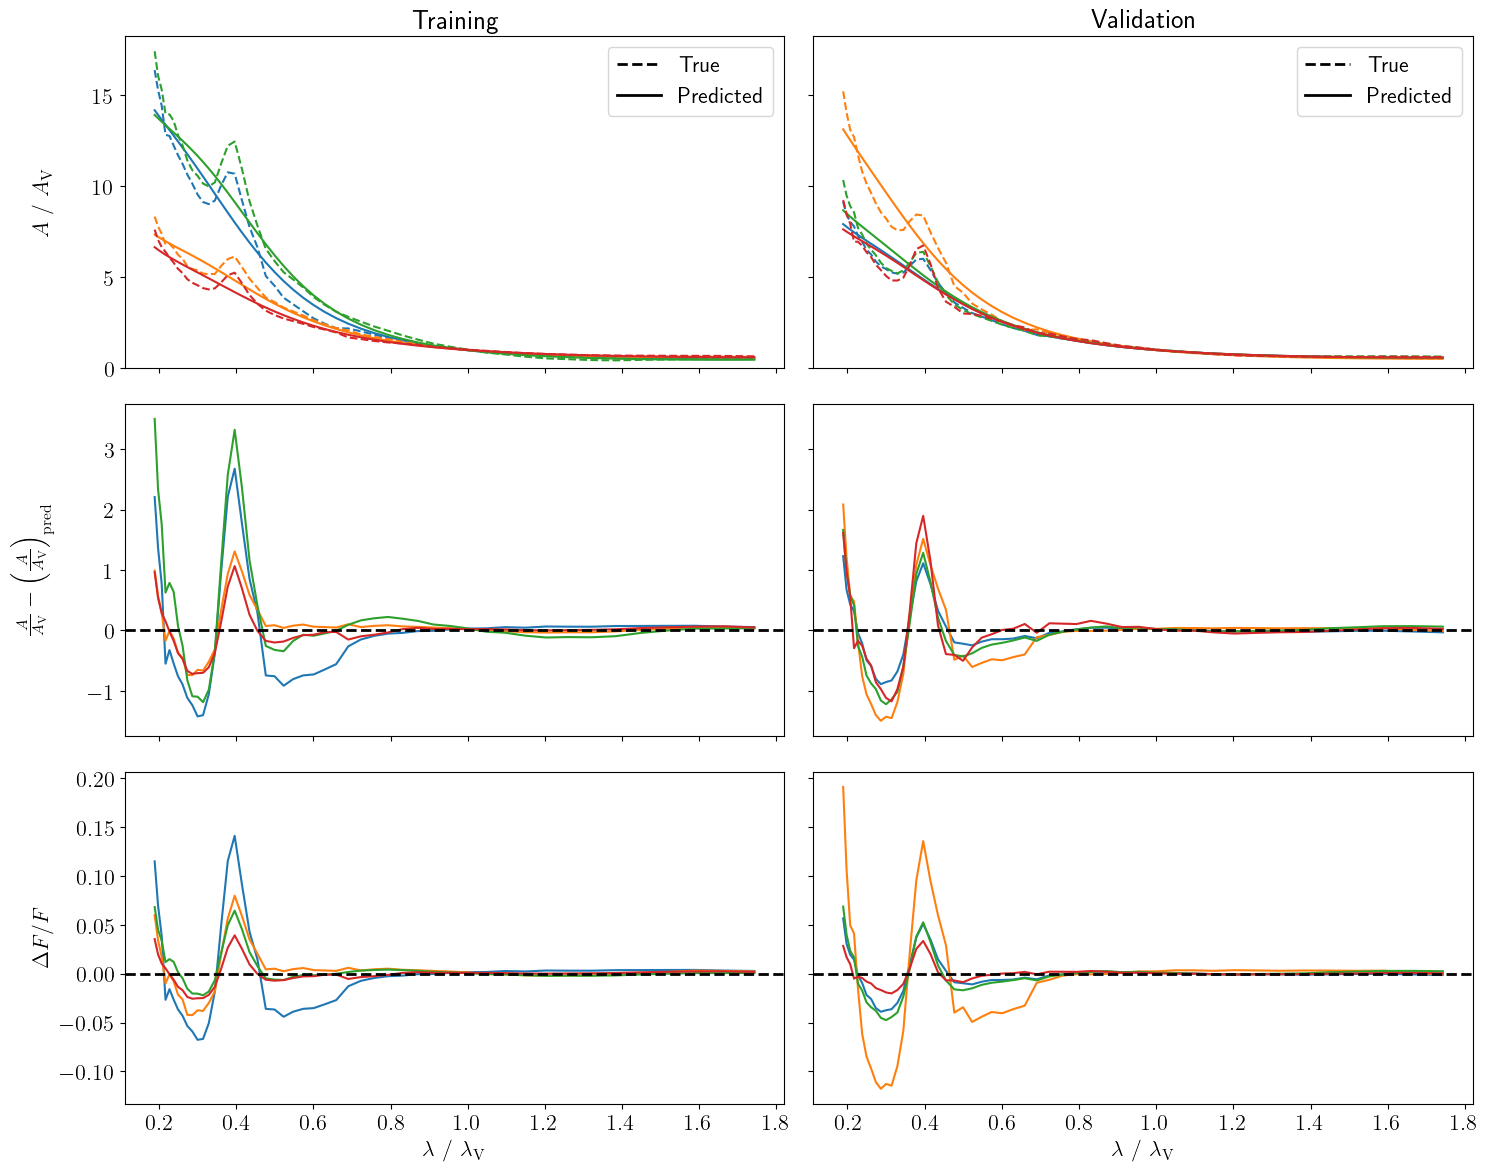

In [50]:
ini_file = 'conf/iob_0.ini'; ilen = None
processing_fun.plot_pareto(ini_file, ilen=ilen, prefix='c')
processing_fun.prediction_plots(ini_file, ilen=ilen, plot_frac_error=False);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=4, offset=0, plot_av_diff=True, plot_dF_F=True);
# processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=False);

Test output code


Reading from configuration file: conf/iob_6.ini
1.1562242401210138e-06
0.6440796931067786


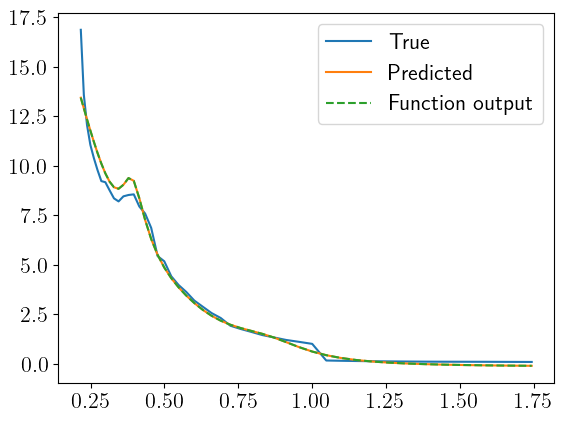

In [70]:
name = 'train'
ini_file = 'conf/iob_6.ini'; ilen = 32

all_data = pd.read_csv('../data/gal_los_iobcomp_attcurve_galprop.dat', sep='\t')
matches = pd.read_csv(f'../symbolic_regression/data/iob_data_10/iob_{name}_galaxy_ids_los.txt', sep='\t',)
matches.rename(columns={"# galaxy_id": "galaxy_id"}, inplace=True)
data_train = all_data.merge(matches, on=['galaxy_id', 'los'], how='inner')
fit_data = pd.read_csv("../data/galaxy_optimization_results.csv")
fit_data.rename(columns={"gal_id": "galaxy_id"}, inplace=True)
data_train = data_train.merge(fit_data, on=['galaxy_id', 'los'], how='inner')

# Get AV
attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
v_index = processing_fun.find_nearest(lam_arr,0.551)

# Get operon data
args = OperonArgs(ini_file)
run_name = f'{args.in_param}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = f'{out_dir}/{run_name}_fun.csv'
df = pd.read_csv(fname, delimiter=';')
if ilen is None:
    eq_idx = -1
else:
    eq_idx = list(df['Length']).index(ilen)
length = list(df['Length'])[eq_idx]
fname = f'{out_dir}/{run_name}_{name}_{length}.csv'
data = np.loadtxt(fname)
ytrue = data[:,args.npar+1]
ypred = data[:,args.npar+2]
if args.fit_log:
    ypred = 10. ** ypred
    ytrue = 10. ** ytrue
fname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_data.txt')
with open(fname, 'r') as f:
    header = f.readline().split()
lam = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
ypred = ypred.reshape(-1, len(lam))
ytrue = ytrue.reshape(-1, len(lam))

for i in [4]:
    gal_id = matches['galaxy_id'].values[i]
    los = matches['los'].values[i]
    row = data_train[(data_train['galaxy_id'] == gal_id) & (data_train['los'] == los)]
    iob_cols = sorted([col for col in row.columns if re.match(r'IOB\d+', col)])
    IOB = row[iob_cols].values[0]
    B = sr_fun.compute_initial_B(IOB)
    new_pred = sr_fun.compute_Av(lam, *B)

    plt.plot(lam, ytrue[i], label='True')
    plt.plot(lam, ypred[i], label='Predicted')
    plt.plot(lam, new_pred, label='Function output', ls='--')
    plt.legend()

    print(np.sqrt(np.mean((new_pred - ypred[i])**2)))
    print(np.sqrt(np.mean((ypred[i] - ytrue[i])**2)))

# A_err_op = [None] * getattr(args, f'n{name}')
# df_F_op = [None] * getattr(args, f'n{name}')
# for j in range(getattr(args, f'n{name}')):
#     A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
#     df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]

# # Get AV
# attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
# lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
# v_index = processing_fun.find_nearest(lam_arr,0.551)
# Av_name = attenuation_cols[v_index]
# Av = data_train[Av_name].values



# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


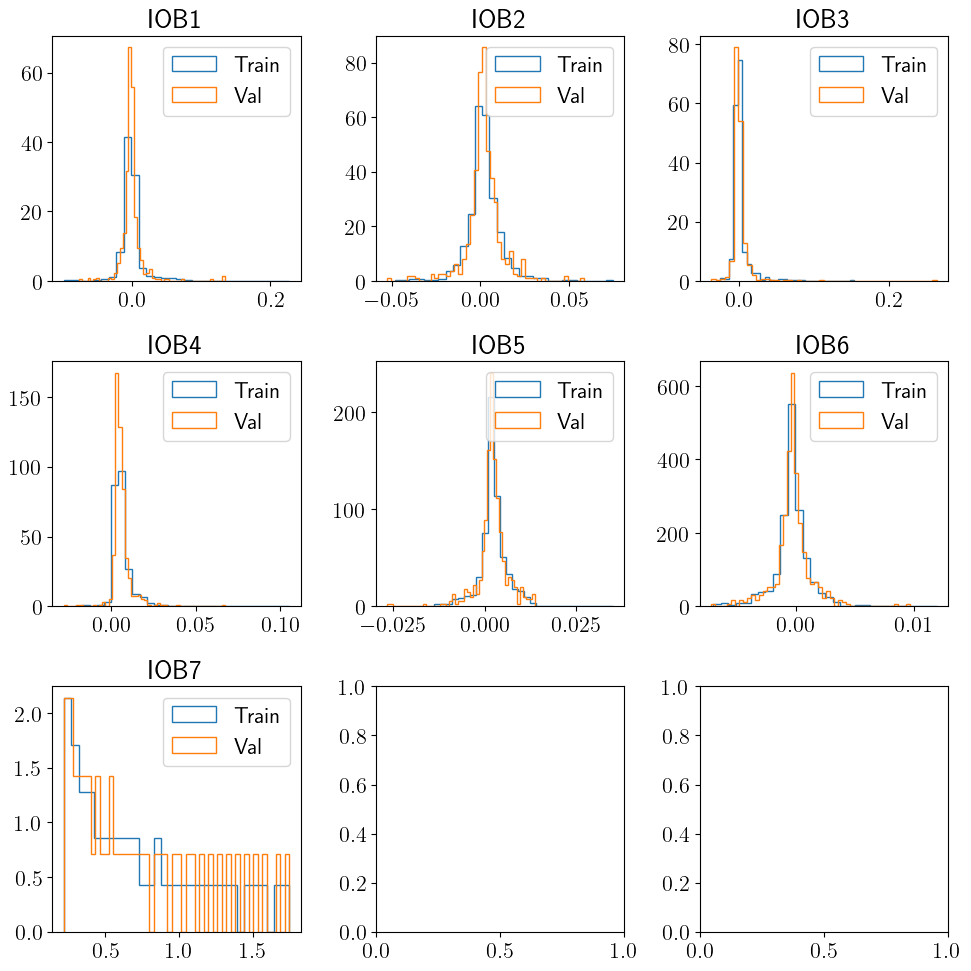

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()